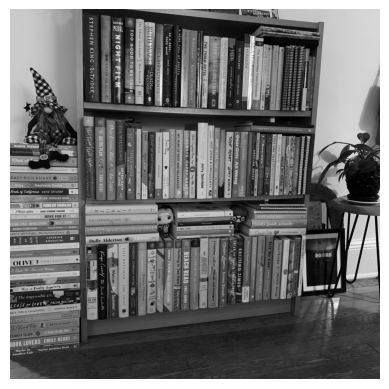

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("bookshelf.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

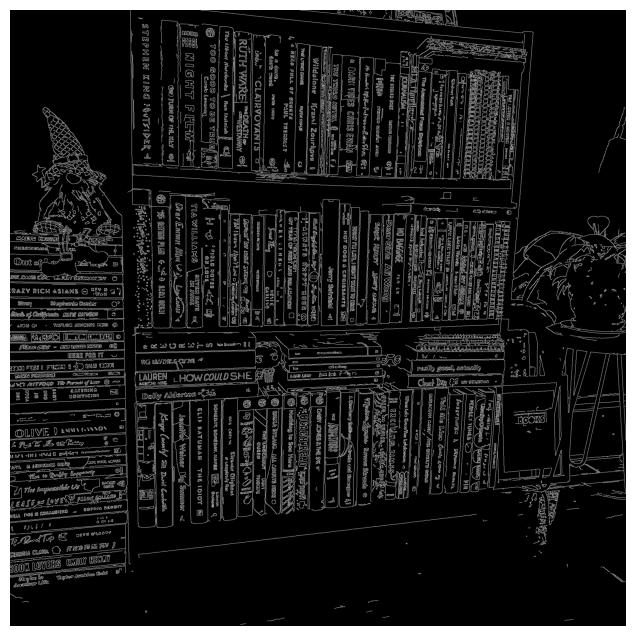

In [2]:
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(12,8))
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

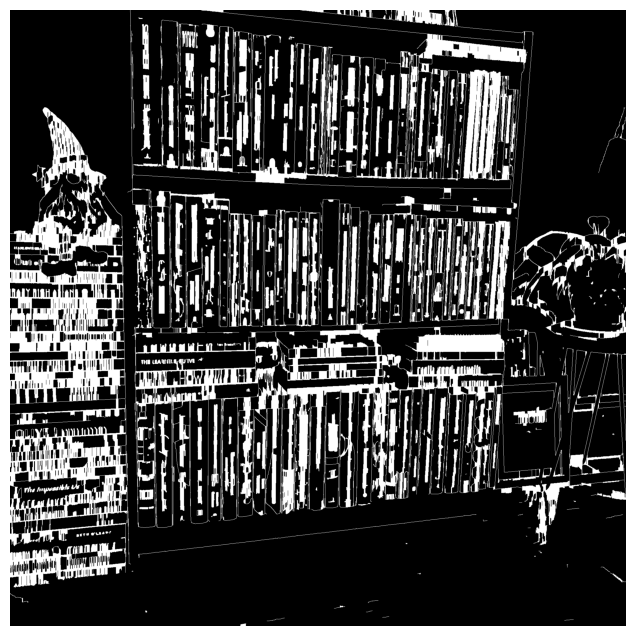

In [3]:
import numpy as np

kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (1,15)
)

vertical = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(12,8))
plt.imshow(vertical, cmap="gray")
plt.axis("off")
plt.show()

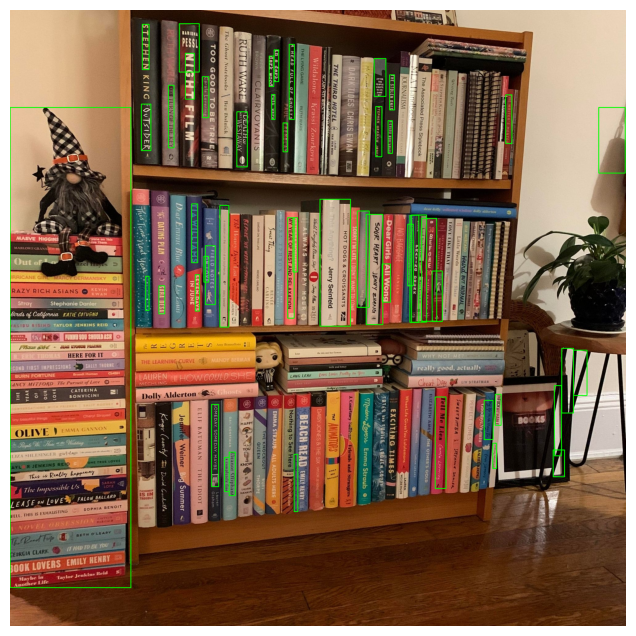

In [7]:
contours, _ = cv2.findContours(
    vertical,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

img_boxes = img.copy()

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    aspect_ratio = h / w

    if (
        h > 80 and
        w > 10 and
        aspect_ratio > 2
    ):
        cv2.rectangle(
            img_boxes,
            (x, y),
            (x+w, y+h),
            (0,255,0),
            2
        )

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [8]:
book_boxes = []

for i, (x,y,w,h) in enumerate(book_boxes):

    crop = img[y:y+h, x:x+w]

    cv2.imwrite(f"crops/book_{i}.jpg", crop)

In [9]:
book_boxes = []

for cnt in contours:

    x, y, w, h = cv2.boundingRect(cnt)

    aspect_ratio = h / w

    if (
        h > 80 and
        w > 10 and
        aspect_ratio > 2
    ):
        book_boxes.append((x, y, w, h))

In [10]:
import os

os.makedirs("crops", exist_ok=True)

In [11]:
for i, (x, y, w, h) in enumerate(book_boxes):

    crop = img[y:y+h, x:x+w]

    cv2.imwrite(
        f"crops/book_{i}.jpg",
        crop
    )

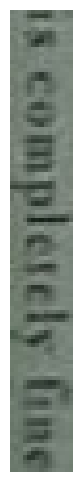

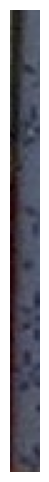

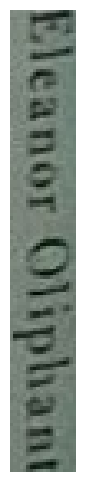

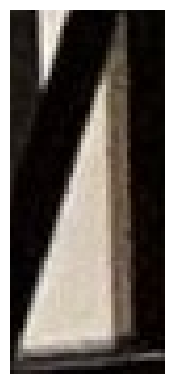

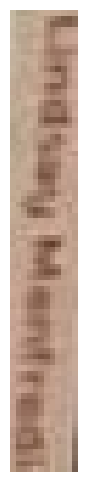

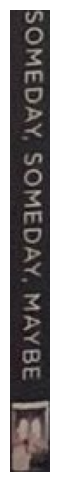

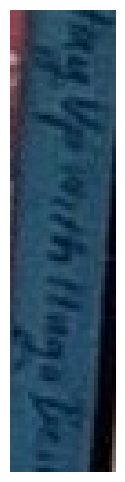

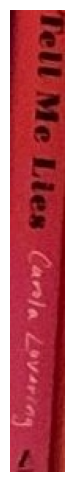

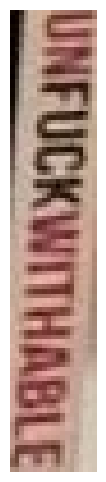

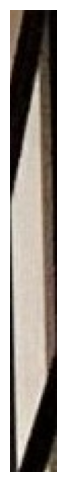

In [12]:
import matplotlib.pyplot as plt

for i in range(min(10, len(book_boxes))):

    crop = cv2.imread(f"crops/book_{i}.jpg")

    plt.figure(figsize=(2,6))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [13]:
for i, (x,y,w,h) in enumerate(book_boxes[:5]):
    print(f"Book {i}: {w} x {h}")

Book 0: 15 x 111
Book 1: 12 x 186
Book 2: 20 x 141
Book 3: 37 x 87
Book 4: 12 x 82
